In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import os
import random
import pandas as pd

In [2]:
from models.dcgan import Generator, Discriminator, weights_init
from models.training import training
from models.results import display_results, save_fake_imgs, generate_interpol_dcgan, calculate_fid
from dataset.CatsDS import CatsDS

Running cfg0_nz100_ngf64_ndf64_lr0.0002_epochs5_beta10.5_seed42, seed=42
Starting Training Loop...
[0/5][0/1]	Loss_D: 1.8030	Loss_G: 5.0050	D(x): 0.3143	D(G(z)): 0.3729 / 0.0098
[1/5][0/1]	Loss_D: 0.7262	Loss_G: 7.8814	D(x): 0.9840	D(G(z)): 0.4536 / 0.0005
[2/5][0/1]	Loss_D: 0.3410	Loss_G: 7.9431	D(x): 0.9875	D(G(z)): 0.2628 / 0.0004
[3/5][0/1]	Loss_D: 0.0951	Loss_G: 7.3043	D(x): 0.9855	D(G(z)): 0.0734 / 0.0008
[4/5][0/1]	Loss_D: 0.0569	Loss_G: 6.1392	D(x): 0.9868	D(G(z)): 0.0414 / 0.0025
Training complete in 0m 1s


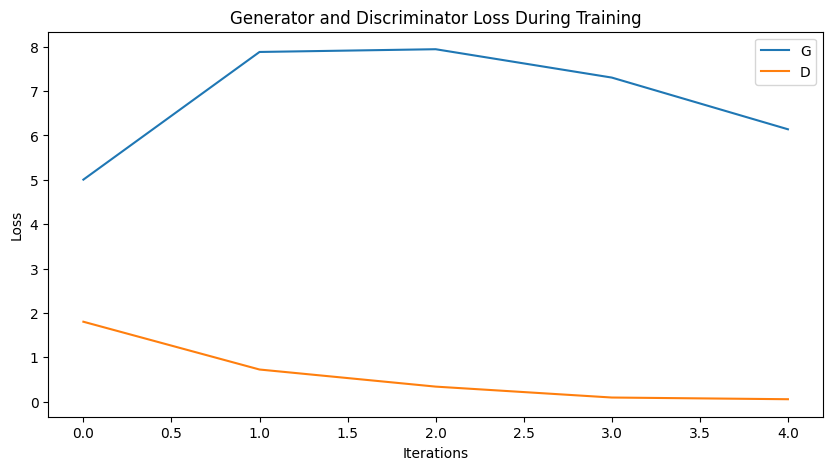

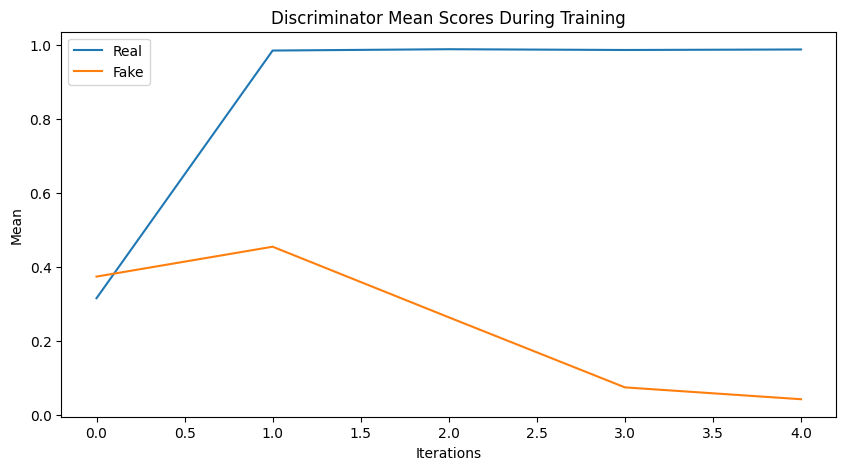

FID: 440.4566345214844
Running cfg1_nz100_ngf64_ndf64_lr0.0002_epochs10_beta10.5_seed42, seed=42
Starting Training Loop...
[0/10][0/1]	Loss_D: 1.8031	Loss_G: 5.0052	D(x): 0.3143	D(G(z)): 0.3729 / 0.0098
[1/10][0/1]	Loss_D: 0.7245	Loss_G: 7.8797	D(x): 0.9840	D(G(z)): 0.4530 / 0.0006
[2/10][0/1]	Loss_D: 0.3450	Loss_G: 7.9702	D(x): 0.9875	D(G(z)): 0.2651 / 0.0004
[3/10][0/1]	Loss_D: 0.0939	Loss_G: 7.3164	D(x): 0.9854	D(G(z)): 0.0721 / 0.0008
[4/10][0/1]	Loss_D: 0.0559	Loss_G: 6.1104	D(x): 0.9868	D(G(z)): 0.0405 / 0.0025
[5/10][0/1]	Loss_D: 0.1387	Loss_G: 6.6705	D(x): 0.9884	D(G(z)): 0.1080 / 0.0017
[6/10][0/1]	Loss_D: 0.1997	Loss_G: 8.0839	D(x): 0.9853	D(G(z)): 0.1476 / 0.0004
[7/10][0/1]	Loss_D: 0.0671	Loss_G: 7.0574	D(x): 0.9728	D(G(z)): 0.0376 / 0.0009
[8/10][0/1]	Loss_D: 0.0929	Loss_G: 6.7110	D(x): 0.9764	D(G(z)): 0.0657 / 0.0014
[9/10][0/1]	Loss_D: 0.0576	Loss_G: 6.7347	D(x): 0.9778	D(G(z)): 0.0337 / 0.0015
Training complete in 0m 1s


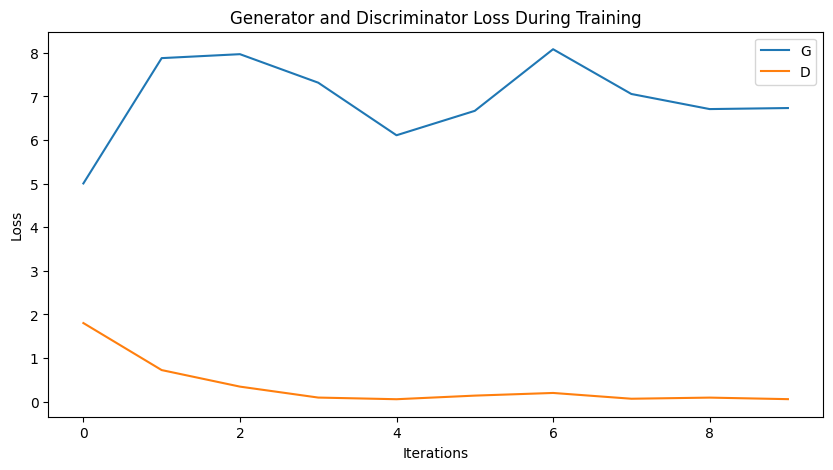

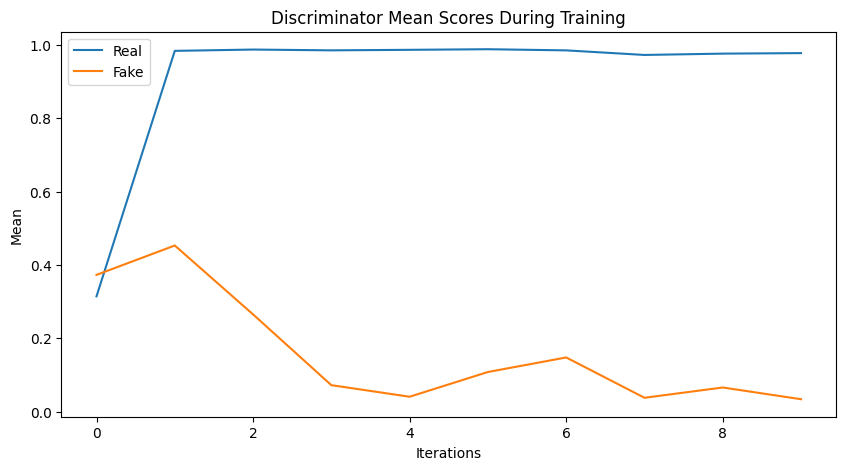

FID: 447.4356994628906


ModuleNotFoundError: No module named 'openpyxl'

In [ ]:
# ========== Fixed Params ==========
main_dir = os.path.join('experiments', 'dcgan')
if not os.path.exists(main_dir):
    os.mkdir(main_dir)
dataroot = os.path.join(os.path.join('data', 'cats'), 'Data')
workers = 2
batch_size = 128
image_size = 64
nc = 3 # Number of channels in the training images
ngpu = 1 if torch.cuda.is_available() else 0
device = torch.device("cuda:0" if ngpu > 0 else "cpu")
seed = 42


# ========== Configurations ==========

# nz - Size of z latent vector (i.e. size of generator input)
# ngf - Size of feature maps in generator
# ndf - Size of feature maps in discriminator
# num_epochs - Number of training epochs
# lr - Learning rate for optimizers
# beta1 - Beta1 hyperparameter for Adam optimizers

configs = [
    {'nz': 100, 'ngf': 64, 'ndf': 64, 'lr': 0.0002, 'num_epochs': 5, 'beta1': 0.5},

    {'nz': 120, 'ngf': 64, 'ndf': 64, 'lr': 0.0002, 'num_epochs': 5, 'beta1': 0.5},
    {'nz': 64, 'ngf': 64, 'ndf': 64, 'lr': 0.0002, 'num_epochs': 5, 'beta1': 0.5},

    {'nz': 100, 'ngf': 32, 'ndf': 64, 'lr': 0.0002, 'num_epochs': 5, 'beta1': 0.5},
    {'nz': 100, 'ngf': 128, 'ndf': 64, 'lr': 0.0002, 'num_epochs': 5, 'beta1': 0.5},

    {'nz': 100, 'ngf': 64, 'ndf': 32, 'lr': 0.0002, 'num_epochs': 5, 'beta1': 0.5},
    {'nz': 100, 'ngf': 64, 'ndf': 128, 'lr': 0.0002, 'num_epochs': 5, 'beta1': 0.5},

    {'nz': 100, 'ngf': 64, 'ndf': 64, 'lr': 0.0001, 'num_epochs': 5, 'beta1': 0.5},
    {'nz': 100, 'ngf': 64, 'ndf': 64, 'lr': 0.0003, 'num_epochs': 5, 'beta1': 0.5},

    {'nz': 100, 'ngf': 64, 'ndf': 64, 'lr': 0.0002, 'num_epochs': 10, 'beta1': 0.5},
    {'nz': 100, 'ngf': 64, 'ndf': 64, 'lr': 0.0002, 'num_epochs': 15, 'beta1': 0.5},

    {'nz': 100, 'ngf': 64, 'ndf': 64, 'lr': 0.0002, 'num_epochs': 5, 'beta1': 0.6},
    {'nz': 100, 'ngf': 64, 'ndf': 64, 'lr': 0.0002, 'num_epochs': 5, 'beta1': 0.4},
]

# ========== Prepare Dataset ==========
dataset = CatsDS(dataroot,
    transform=transforms.Compose([
        transforms.Resize(image_size),
        transforms.CenterCrop(image_size),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ])
)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size,
                                         shuffle=True, num_workers=workers)

# ========== Run Experiments ==========
results = []

for cfg_idx, config in enumerate(configs):
    nz, ngf, ndf, lr, num_epochs, beta1 = config['nz'], config['ngf'], config['ndf'], config['lr'], config['num_epochs'], config['beta1']
    experiment_name = f"cfg{cfg_idx}_nz{nz}_ngf{ngf}_ndf{ndf}_lr{lr}_epochs{num_epochs}_beta1{beta1}_seed{seed}"
    experiment_dir = os.path.join(main_dir, experiment_name)
    if not os.path.exists(experiment_dir):
        os.mkdir(experiment_dir)
    #fids = []

    # for run_idx, seed in enumerate([0, 1, 2]):
    print(f"Running {experiment_name}, seed={seed}")
    torch.manual_seed(seed)
    random.seed(seed)

    # Initialize models
    netG = Generator(ngpu, nz=nz, ngf=ngf, nc=nc).to(device)
    netD = Discriminator(ngpu, ndf=ndf, nc=nc).to(device)
    if device.type == 'cuda' and ngpu > 1:
        netG = nn.DataParallel(netG, list(range(ngpu)))
        netD = nn.DataParallel(netD, list(range(ngpu)))
    netG.apply(weights_init)
    netD.apply(weights_init)

    # Optimizers and criterion
    criterion = nn.BCELoss()
    optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))
    optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))

    # Train
    run_dir = experiment_dir # if run_idx == 0 else None
    training(num_epochs, nz, dataloader, netD, netG, device, criterion, optimizerD, optimizerG, run_dir)

    # Evaluation + image generation only once
    if run_dir:
        display_results(run_dir)
        save_fake_imgs(ngpu, nz, ngf, nc, device, run_dir, random_state=seed)
        generate_interpol_dcgan(run_dir, ngpu, nz, ngf, nc, device)

    # # FID computation (assumes save_fake_imgs saves images in run_dir + "/fake_images")
    # fid = calculate_fid(real_path=dataroot, fake_path=os.path.join(run_dir, "fake_images"))
    # fids.append(fid)

    # mean_fid = sum(fids) / len(fids)
    # std_fid = (sum([(f - mean_fid) ** 2 for f in fids]) / len(fids)) ** 0.5
    # results.append({
    #     "config": experiment_name,
    #     "nz": nz, "ngf": ngf, "ndf": ndf, "lr": lr,
    #     "FID_mean": mean_fid, "FID_std": std_fid
    # })
    fid = calculate_fid(
        real_path=dataroot,
        fake_path=os.path.join(run_dir, 'fake_imgs'),
        device=device
    )
    results.append({
        "config": experiment_name,
        "nz": nz, "ngf": ngf, "ndf": ndf, "lr": lr, "epochs": num_epochs, "beta1": beta1,
        f"fid_{seed}": fid
    })
    print("FID:", fid)


# ========== Save Results ==========
df = pd.DataFrame(results)
df.to_excel(os.path.join(main_dir, "fid_results.xlsx"), index=False)
print("Results saved to:", os.path.join(main_dir, "fid_results.xlsx"))
